# Notebook 1: Qubit Visualization and Born Rule

This notebook is part of the introductory hands-on materials for the FDP Session on Quantum Computing. It covers:
1. State preparation of single qubits and Bloch sphere visualizations.
2. Extracting statevector amplitudes and exact probabilities.
3. Simulating measurements using finite shots to observe statistical convergence.
4. Visualizing quantum interference and phase dependency.

We will use both **PennyLane** and **Qiskit** to illustrate these concepts.

## Section 1: State Preparation and Bloch Sphere Visualization

PennyLane uses a `device` and `qnode` model to construct and run quantum circuits. Let us build single-qubit states using rotations on the initial state $|0\rangle$:
$$|\psi\rangle = R_z(\phi)R_y(\theta)|0\rangle = \cos\frac{\theta}{2}|0\rangle + e^{i\phi}\sin\frac{\theta}{2}|1\rangle$$

We then print the PennyLane circuit diagram and plot the resulting state on the Bloch sphere.

In [1]:
import pennylane as qml
import numpy as np
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from IPython.display import display

# Define a statevector simulator device
dev = qml.device("default.qubit", wires=1)

# Define a QNode that returns the statevector
@qml.qnode(dev)
def prepare_qubit_state(theta, phi):
    # We initialize in |0>
    # Apply Ry(theta) then Rz(phi) to set the Bloch sphere coordinates
    qml.RY(theta, wires=0)
    qml.RZ(phi, wires=0)
    return qml.state()

# Test preparing the state for theta = pi/3, phi = pi/4
theta = np.pi / 3
phi = np.pi / 4
state = prepare_qubit_state(theta, phi)
print("Statevector:", state)

Statevector: [0.80010315-0.33141357j 0.46193977+0.19134172j]


PennyLane Circuit Diagram:
0: ──RY(1.05)──RZ(0.79)─┤  State


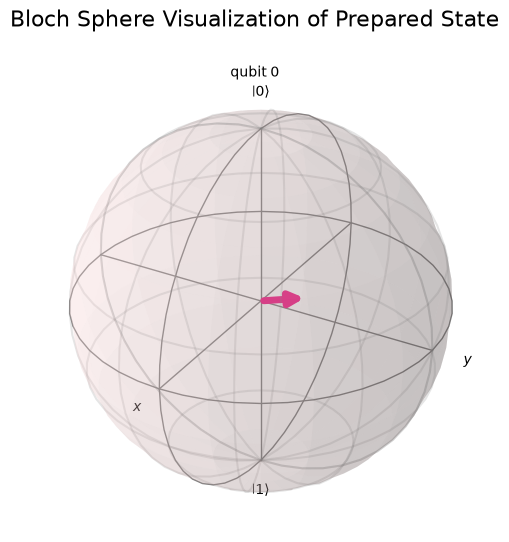

In [2]:
# 1. Draw the PennyLane Circuit
print("PennyLane Circuit Diagram:")
print(qml.draw(prepare_qubit_state)(theta, phi))

# 2. Visualize on the Bloch Sphere
# We wrap the PennyLane state in a Qiskit Statevector for visualization
sv = Statevector(state)
fig = plot_bloch_multivector(sv, title="Bloch Sphere Visualization of Prepared State")
display(fig)

## Section 2: Amplitudes, Born Rule, and Finite Shots

Under the Born rule, the probability of obtaining outcome $x \in \{0, 1\}$ is given by the squared magnitude of its amplitude:
$$P(0) = |\alpha|^2, \qquad P(1) = |\beta|^2$$

Let's write code to extract these exact amplitudes, print the PennyLane shot-based circuit, and compare it with simulated shot counts using **Qiskit**.

In [3]:
# Exact amplitudes and probabilities
alpha = state[0]
beta = state[1]

p0_exact = np.abs(alpha)**2
p1_exact = np.abs(beta)**2

print(f"alpha (amplitude of |0>): {alpha:.4f}  |  P(0) exact: {p0_exact:.4f}")
print(f"beta  (amplitude of |1>): {beta:.4f}  |  P(1) exact: {p1_exact:.4f}")

alpha (amplitude of |0>): 0.8001-0.3314j  |  P(0) exact: 0.7500
beta  (amplitude of |1>): 0.4619+0.1913j  |  P(1) exact: 0.2500


In [4]:
# 1. Define PennyLane shot-based simulator
dev_shots = qml.device("default.qubit", wires=1, shots=1000)

@qml.qnode(dev_shots)
def prepare_qubit_state_shots(theta, phi):
    qml.RY(theta, wires=0)
    qml.RZ(phi, wires=0)
    return qml.counts(qml.PauliZ(0))

print("PennyLane Shot-Based Circuit Diagram:")
print(qml.draw(prepare_qubit_state_shots)(theta, phi))

# Run counts in PennyLane (measures +1 for |0> and -1 for |1> by default for PauliZ)
# We map them back to |0> and |1> counts
raw_counts = prepare_qubit_state_shots(theta, phi)
pl_counts = {'0': raw_counts.get(1, 0), '1': raw_counts.get(-1, 0)}
print("PennyLane 1000-shot counts:", pl_counts)

# 2. Run for different shot counts in Qiskit for comparison
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(1)
qc.ry(theta, 0)
qc.rz(phi, 0)
qc.measure_all()

sim = AerSimulator()
for shots in [100, 1000, 10000]:
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    freqs = {k: v / shots for k, v in counts.items()}
    print(f"Qiskit Shots: {shots:5} | Sampled Frequencies: {freqs}")

PennyLane Shot-Based Circuit Diagram:
0: ──RY(1.05)──RZ(0.79)─┤  Counts[Z]
PennyLane 1000-shot counts: {'0': np.int64(723), '1': np.int64(277)}
Qiskit Shots:   100 | Sampled Frequencies: {'1': 0.26, '0': 0.74}
Qiskit Shots:  1000 | Sampled Frequencies: {'1': 0.245, '0': 0.755}
Qiskit Shots: 10000 | Sampled Frequencies: {'1': 0.2492, '0': 0.7508}


/Users/quantsha/venv_mac/lib/python3.12/site-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


## Section 3: Phase Dependency and Quantum Interference

A relative phase $\phi$ is invisible under *direct* $Z$-basis measurement. 
However, applying a Hadamard gate $H$ before measurement rotates the basis, mapping the relative phase information into measurable amplitude differences.

Let's write a PennyLane interference circuit, draw it, and plot the Bloch sphere representation of the qubit both **before** and **after** the basis-rotation Hadamard gate.

In [5]:
# 1. Define PennyLane interference QNode
@qml.qnode(dev)
def interference_circuit_pl(phi, apply_hadamard=True):
    # Prepare equator state (theta = pi/2)
    qml.RY(np.pi / 2, wires=0)
    qml.RZ(phi, wires=0)
    if apply_hadamard:
        qml.Hadamard(wires=0)
    return qml.state()

print("PennyLane Interference Circuit (with basis rotation):")
print(qml.draw(interference_circuit_pl)(np.pi / 4, apply_hadamard=True))

# 2. Show phase measurement statistics in Qiskit
print("\nQiskit Measurement after Hadamard (revealing phase)")
for test_phi in [0, np.pi / 4, np.pi / 2, np.pi]:
    qc_test = QuantumCircuit(1)
    qc_test.ry(np.pi / 2, 0)
    qc_test.rz(test_phi, 0)
    qc_test.h(0)
    sv_test = Statevector.from_instruction(qc_test)
    probs = sv_test.probabilities_dict()
    print(f"phi: {test_phi/np.pi:4.2f}*pi | P(0): {probs.get('0', 0.0):.4f} | P(1): {probs.get('1', 0.0):.4f}")

PennyLane Interference Circuit (with basis rotation):
0: ──RY(1.57)──RZ(0.79)──H─┤  State

Qiskit Measurement after Hadamard (revealing phase)
phi: 0.00*pi | P(0): 1.0000 | P(1): 0.0000
phi: 0.25*pi | P(0): 0.8536 | P(1): 0.1464
phi: 0.50*pi | P(0): 0.5000 | P(1): 0.5000
phi: 1.00*pi | P(0): 0.0000 | P(1): 1.0000


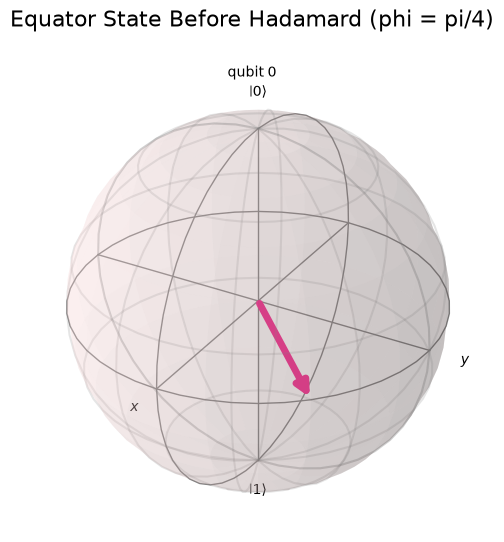

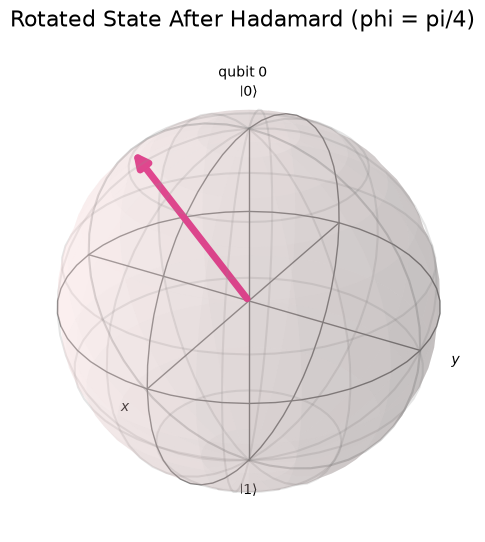

In [6]:
# 3. Plot Bloch Spheres to show the effect of the basis-rotation Hadamard
test_phi = np.pi / 4

# A. State on the equator (before Hadamard)
state_before = interference_circuit_pl(test_phi, apply_hadamard=False)
sv_before = Statevector(state_before)
fig_before = plot_bloch_multivector(sv_before, title="Equator State Before Hadamard (phi = pi/4)")
display(fig_before)

# B. State after Hadamard rotation (mapped to Z axis)
state_after = interference_circuit_pl(test_phi, apply_hadamard=True)
sv_after = Statevector(state_after)
fig_after = plot_bloch_multivector(sv_after, title="Rotated State After Hadamard (phi = pi/4)")
display(fig_after)